# US 4.3.1 — Optimización de Hiperparámetros

**Entregable:** Tabla comparativa de configuraciones default vs. óptimas
**Criterio de aceptación:** Configuración óptima documentada con mejora cuantificable respecto a la versión base

## Objetivo

El ajuste fino de hiperparámetros es una etapa crítica en el desarrollo de modelos de aprendizaje profundo para imputación. Los modelos entrenados en US 4.1 y US 4.2 utilizaron configuraciones default razonables pero no necesariamente óptimas para el problema específico de imputación hidrometeorológica de Sinaloa. Este notebook implementa una búsqueda sistemática de hiperparámetros que maximiza el rendimiento en el conjunto de validación manteniendo generalización.

## Modelos optimizados

Se seleccionaron los **cuatro modelos** con mayor NSE promedio en las fases anteriores, representando tres familias distintas:

| Modelo | Familia | NSE base | Hiperparámetros clave |
|--------|---------|----------|----------------------|
| BRITS   | Generativo — RNN bidireccional con decaimiento temporal | 0.626 | hidden_size, lr, w_consist, w_est |
| SAITS   | Generativo — Transformer (DMSA) | 0.592 | d_model, n_heads, n_layers, lr, w_mit |
| XGBoost | Base — Gradient Boosting tabular | 0.646 | n_estimators, max_depth, lr, subsample |
| BiGRU   | Base — RNN bidireccional simple | 0.644 | hidden_size, n_layers, dropout, lr |

BiGRU se incorpora como **referencia neuronal de alta calidad**: con NSE = 0.6438 fue el segundo mejor modelo en US 4.1, superando al resto de los modelos base. Su inclusión permite determinar si los modelos generativos (BRITS, SAITS), con mayor complejidad computacional y teórica, ofrecen una ganancia real sobre una arquitectura recurrente estándar una vez ambas son optimizadas en igualdad de condiciones.

## Algoritmo de búsqueda: Optuna TPE + MedianPruner

Se utiliza **Optuna** (Akiba et al., 2019) con el sampler **Tree-structured Parzen Estimator (TPE)**, que modela probabilísticamente la función objetivo y concentra los trials en regiones del espacio de hiperparámetros con mayor potencial de mejora. Esto lo hace superior a la búsqueda en grilla (que crece exponencialmente) y al random search (que no aprende de trials anteriores).

El **MedianPruner** aborta trials poco prometedores antes de completar todas las épocas, reduciendo el costo computacional total en ~40–60 %.

**Justificación del número de trials (25):** el sampler TPE requiere aproximadamente 20 trials en fase de exploración cuasi-aleatoria para construir un modelo probabilístico confiable del espacio de hiperparámetros. Con 25 trials se garantiza que el algoritmo supera esa fase y dispone de al menos 5 trials de explotación efectiva. Este presupuesto es una adaptación al costo computacional en CPU — en la literatura con GPU se reportan 50–100 trials (Du et al., 2023); en CPU el MedianPruner compensa parcialmente esta reducción al eliminar trials claramente subóptimos antes de completar todas las épocas, maximizando la información útil por unidad de tiempo de cómputo.

**Presupuesto de búsqueda:** 25 trials × **30 épocas** (BRITS, BiGRU — protocolo Cao et al., 2018) | 25 trials × **20 épocas** (SAITS — protocolo Du et al., 2023) | 50 trials (XGBoost) | 40 % del conjunto de entrenamiento como sub-muestra para velocidad.

**Re-entrenamiento final:** una vez identificada la configuración óptima, cada modelo se re-entrena sobre el **100 % de los datos de entrenamiento** con **early stopping** (patience = 15 épocas, min_delta = 1×10⁻⁵, máximo 150 épocas). Esto garantiza que las métricas reportadas corresponden a un modelo completamente convergido, no a una aproximación de búsqueda.

In [7]:
from pathlib import Path
import json, time, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
try:
    import xgboost as xgb
    XGB_OK = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    XGB_OK = False
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False
    print("optuna no disponible -- pip install optuna")

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path("__file__").resolve().parent.parent
TENSORS_DIR  = PROJECT_ROOT / "data" / "tensors"
SPLITS_DIR   = PROJECT_ROOT / "data" / "splits"
MODELS_OPT   = PROJECT_ROOT / "models" / "optimizacion"
REPORTS_OPT  = PROJECT_ROOT / "reports" / "optimizacion"
FIGURES_OPT  = REPORTS_OPT / "figuras"
for d in [MODELS_OPT, REPORTS_OPT, FIGURES_OPT]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
VARIABLES = ["precip", "evap", "tmax", "tmin"]
MCAR_RATE = 0.20
print(f"Device  : {DEVICE}")
print(f"Optuna  : {OPTUNA_OK}")
print(f"XGBoost : {XGB_OK}")

Device  : cpu
Optuna  : True
XGBoost : True


## 1 — Carga de tensores y configuración de búsqueda

Se cargan los tensores pre-procesados del pipeline (US 3.x) con formato `(N, 30, 4)`:

- **X**: valores escalados, NaN reemplazado con 0
- **mask**: 1 = observado, 0 = faltante natural
- **delta**: días transcurridos desde la última observación (requerido por BRITS)

### Estrategia de sub-muestreo para la búsqueda

Entrenar cada trial sobre las 160,041 secuencias completas de train haría inviable la búsqueda (horas por trial). Se usa un **sub-muestro aleatorio del 40 %** (~64,000 secuencias), suficiente para capturar la variabilidad estacional del dominio hidrometeorológico de Sinaloa, que cubre 4 variables × 173 estaciones × 6 décadas.

La evaluación de cada trial se realiza sobre las primeras 10,000 secuencias del conjunto de **validación completo** para garantizar una estimación estable de la función objetivo.

### Función objetivo: NSE negativo

La función objetivo de cada trial de Optuna es el **NSE negativo** sobre el conjunto de validación (se minimiza porque Optuna minimiza por defecto):

| Valor NSE | Interpretación |
|-----------|---------------|
| NSE = 1 | Ajuste perfecto — error cero |
| NSE = 0 | Equivale a predecir la media de la serie |
| NSE < 0 | Peor que predecir la media |

NSE es la métrica estándar en hidrología (Nash & Sutcliffe, 1970) y captura tanto el sesgo como la varianza del error, penalizando más los errores grandes que el MAE.

In [8]:
def load_tensor(p):
    try:    return torch.load(p, weights_only=True)
    except: return torch.load(p)

X_train = load_tensor(TENSORS_DIR / "X_train.pt")
M_train = load_tensor(TENSORS_DIR / "mask_train.pt")
D_train = load_tensor(TENSORS_DIR / "delta_train.pt")
X_val   = load_tensor(TENSORS_DIR / "X_val.pt")
M_val   = load_tensor(TENSORS_DIR / "mask_val.pt")
D_val   = load_tensor(TENSORS_DIR / "delta_val.pt")

with open(TENSORS_DIR / "tensors_metadata.json") as f:
    meta = json.load(f)

N_FEAT, WIN_SIZE = X_train.shape[2], X_train.shape[1]
N_SEARCH   = int(len(X_train) * 0.40)   # 40 % para búsqueda rápida
N_EPOCHS_BRITS = 30   # Cao et al. (2018) — protocolo original BRITS
N_EPOCHS_SAITS = 20   # Du et al. (2023) — protocolo original SAITS
N_EPOCHS_BIGRU = 30   # RNN bidireccional, misma familia que BRITS
N_TRIALS_DL   = 25
N_TRIALS_XGB  = 50
N_EPOCHS_FINAL = 150   # techo de épocas para re-entrenamiento final
PATIENCE       = 15    # épocas sin mejora para early stopping
MIN_DELTA      = 1e-5  # mejora mínima considerada real

# Sub-muestras para búsqueda
torch.manual_seed(0)
sub_idx = torch.randperm(len(X_train))[:N_SEARCH]
X_sub, M_sub, D_sub = X_train[sub_idx], M_train[sub_idx], D_train[sub_idx]
val_ds_opt  = TensorDataset(X_val[:10000], M_val[:10000], D_val[:10000])
val_ldr_opt = DataLoader(val_ds_opt, 512, shuffle=False)
print(f"Tensores  -- train: {tuple(X_train.shape)}, val: {tuple(X_val.shape)}")
print(f"Sub-train : {N_SEARCH:,} secuencias  ({N_SEARCH/len(X_train)*100:.0f}%)")
print(f"N_FEAT={N_FEAT}, WIN_SIZE={WIN_SIZE}")
print(f"Búsqueda: BRITS={N_EPOCHS_BRITS} épocas | SAITS={N_EPOCHS_SAITS} épocas | BiGRU={N_EPOCHS_BIGRU} épocas | XGBoost=50 trials")
print(f"Final: early stopping (max {N_EPOCHS_FINAL}, patience {PATIENCE})")

Tensores  -- train: (160041, 30, 4), val: (33831, 30, 4)
Sub-train : 64,016 secuencias  (40%)
N_FEAT=4, WIN_SIZE=30
Búsqueda: BRITS=30 épocas | SAITS=20 épocas | BiGRU=30 épocas | XGBoost=50 trials
Final: early stopping (max 150, patience 15)


## 2 — Arquitecturas paramétricas

Se re-definen las arquitecturas de BRITS, SAITS y BiGRU con todos sus hiperparámetros expuestos como argumentos del constructor, permitiendo que Optuna instancie variantes distintas en cada trial.

### 2a — BRITS (Bidirectional Recurrent Imputation for Time Series)

**Cao et al., 2018** propone BRITS como solución al problema de imputación con datos faltantes irregulares. La arquitectura central es la celda **RITS** (Recurrent Imputation for Time Series), que incorpora tres mecanismos clave:

1. **Decaimiento temporal γ(δ) = exp(−ReLU(Wδ)):** escala el estado oculto y los valores de entrada en función del tiempo transcurrido desde la última observación `δ`. Cuanto mayor el gap, menor la influencia del estado previo — reflejo del principio físico de que series hidrometeorológicas pierden autocorrelación con el tiempo.

2. **Estimación complementaria:** en cada paso temporal, el modelo genera una estimación `x̂ₜ = f(hₜ₋₁)` que complementa los valores faltantes antes de actualizar la celda GRU.

3. **Consistencia bidireccional:** dos celdas RITS (forward y backward) procesan la secuencia en direcciones opuestas. La pérdida de consistencia `||x_fwd − x_bwd||` penaliza discrepancias, actuando como regularizador implícito.

**Hiperparámetros buscados:** `hidden_size` (capacidad representacional), `lr` (tasa de aprendizaje Adam), `w_consist` (peso de la pérdida de consistencia), `w_est` (peso de la pérdida de estimación interna), `batch_size`.

In [9]:
class TemporalDecay(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)
    def forward(self, delta):
        return torch.exp(-F.relu(self.W(delta)))

class RITSCell(nn.Module):
    def __init__(self, n_features=4, hidden_size=64):
        super().__init__()
        self.n_features  = n_features
        self.hidden_size = hidden_size
        self.decay_x  = TemporalDecay(n_features, n_features)
        self.decay_h  = TemporalDecay(n_features, hidden_size)
        self.estimate = nn.Linear(hidden_size, n_features)
        self.gru      = nn.GRUCell(n_features * 2, hidden_size)

    def forward(self, x_seq, m_seq, d_seq):
        N, T, F = x_seq.shape
        h = torch.zeros(N, self.hidden_size, device=x_seq.device)
        ximps, xests = [], []
        for t in range(T):
            x = x_seq[:, t]; m = m_seq[:, t]; d = d_seq[:, t]
            gx = self.decay_x(d);  gh = self.decay_h(d)
            xe  = self.estimate(h)
            xc  = m * x + (1 - m) * xe
            xh  = gx * xc + (1 - gx) * xe
            h   = self.gru(torch.cat([xh, m], -1), gh * h)
            ximps.append(xc.unsqueeze(1));  xests.append(xe.unsqueeze(1))
        return torch.cat(ximps, 1), torch.cat(xests, 1)

class BRITS(nn.Module):
    def __init__(self, n_features=4, hidden_size=64):
        super().__init__()
        self.fwd = RITSCell(n_features, hidden_size)
        self.bwd = RITSCell(n_features, hidden_size)

    def forward(self, x, m, d):
        xf, ef = self.fwd(x, m, d)
        xb, eb = self.bwd(x.flip(1), m.flip(1), d.flip(1))
        xb = xb.flip(1);  eb = eb.flip(1)
        x_imp = (xf + xb) / 2
        l_consist = (xf - xb).abs().mean()
        return x_imp, ef, eb, l_consist

print("BRITS parameterizable: OK")

BRITS parameterizable: OK


### 2b — SAITS (Self-Attention Imputation for Time Series)

**Du et al., 2023** propone SAITS como alternativa basada en Transformers para imputación multivariada. Su componente central es el bloque **DMSA** (Diagonal-Masked Self-Attention), que aplica una máscara diagonal en la matriz de atención para evitar que cada posición temporal se "atienda a sí misma" — un problema específico de la imputación que no existe en traducción o generación de texto.

La función de pérdida combina dos tareas complementarias:

| Tarea | Nombre | Descripción |
|-------|--------|-------------|
| ORT | Observed Reconstruction Task | Reconstruir valores **observados** — fuerza coherencia con la serie original |
| MIT | Masked Imputation Task | Imputar valores **enmascarados artificialmente** — evalúa capacidad generalizadora |

La pérdida total es `L = L_ORT + w_MIT · L_MIT`, donde `w_MIT` controla el balance entre fidelidad y capacidad de imputación.

**Hiperparámetros buscados:** `d_model` (dimensión del espacio de embeddings), `n_heads` (cabezas de atención, debe dividir exactamente a `d_model`), `n_layers` (profundidad del Transformer), `lr`, `dropout`, `w_mit`, `batch_size`.

In [10]:
class FeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.1):
        super().__init__()
        self.net  = nn.Sequential(nn.Linear(d_model, d_model*4), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(d_model*4, d_model),
                                  nn.Dropout(dropout))
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x): return self.norm(x + self.net(x))

class DMSABlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff   = FeedForward(d_model, dropout)
        self.norm = nn.LayerNorm(d_model)
    def forward(self, x, mask=None):
        a, _ = self.attn(x, x, x, attn_mask=mask)
        return self.ff(self.norm(x + a))

class SAITS(nn.Module):
    def __init__(self, n_features=4, window=30, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.emb    = nn.Linear(n_features, d_model)
        self.pos    = nn.Embedding(window, d_model)
        self.blocks = nn.ModuleList([DMSABlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.out    = nn.Linear(d_model, n_features)

    def forward(self, x, m):
        N, T, F = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0).expand(N, -1)
        h   = self.emb(x) + self.pos(pos)
        for blk in self.blocks: h = blk(h)
        xh  = self.out(h)
        return m * x + (1 - m) * xh, xh

print("SAITS parameterizable: OK")

SAITS parameterizable: OK


### 2c — BiGRU (Bidirectional GRU Imputer)

El **BiGRU** es el mejor modelo de la familia base (NSE = 0.6438, US 4.1). Su arquitectura es considerablemente más simple que BRITS: en lugar de decaimiento temporal explícito, informa al modelo de la presencia/ausencia de datos **concatenando la máscara directamente al input**:

```
input = concat([X, mask], dim=-1)  →  (N, T, 2F)
```

Las capas GRU bidireccionales procesan esta secuencia aumentada, y la capa de salida reconstruye los F valores originales. El resultado final mezcla valores observados (sin cambio) con los imputados:

```
output = mask × X + (1 − mask) × GRU_output
```

Esta arquitectura actúa como **referencia competitiva fuerte** para los modelos generativos: si BRITS-opt o SAITS-opt no superan a BiGRU-opt, el modelo generativo no justifica su mayor complejidad computacional.

**Hiperparámetros buscados:** `hidden_size` (capacidad por dirección), `n_layers` (profundidad apilada), `lr`, `dropout`, `batch_size`.

In [11]:
class BiGRUImputer(nn.Module):
    def __init__(self, n_features=4, hidden_size=128, n_layers=2, dropout=0.2):
        super().__init__()
        self.rnn = nn.GRU(
            input_size  = n_features * 2,   # X + mask concatenados
            hidden_size = hidden_size,
            num_layers  = n_layers,
            dropout     = dropout if n_layers > 1 else 0.0,
            batch_first = True,
            bidirectional = True)
        self.out = nn.Linear(hidden_size * 2, n_features)

    def forward(self, x, mask):
        h, _ = self.rnn(torch.cat([x, mask], dim=-1))
        xh   = self.out(h)
        return mask * x + (1 - mask) * xh

print("BiGRUImputer parameterizable: OK")

BiGRUImputer parameterizable: OK


## 3 — Optimización BRITS con Optuna

### Espacio de búsqueda y justificación de rangos

| Hiperparámetro | Rango | Tipo | Justificación |
|---------------|-------|------|--------------|
| `hidden_size` | {32, 64, 128, 256} | categórico | Cubre desde modelos ligeros hasta alta capacidad; 64 fue el default (punto medio) |
| `lr` | [1e-4, 1e-2] log-uniform | continuo | Rango estándar para Adam en series temporales; log-uniform sesga hacia valores pequeños |
| `w_consist` | [0.01, 0.5] log-uniform | continuo | Controla regularización bidireccional; valores muy altos pueden dominar la señal útil |
| `w_est` | [0.01, 0.3] log-uniform | continuo | Peso de la pérdida de estimación interna; rango conservador para no destabilizar el entrenamiento |
| `batch_size` | {128, 256, 512} | categórico | Afecta la estimación del gradiente y la velocidad; 256 fue el default |

### Protocolo MCAR en cada trial

En cada batch de entrenamiento se aplica **MCAR 20 %** adicional sobre la máscara natural: `vis = mask × (rand > 0.20)`. Los valores ocultos artificialmente sirven como ground-truth supervisado. Este protocolo es consistente con el usado en US 4.1 y 4.2, garantizando comparabilidad de métricas.

### Configuración de la búsqueda

**30 épocas por trial** sobre el 40 % del conjunto de entrenamiento (~64,016 secuencias), siguiendo el protocolo de búsqueda de los autores originales (Cao et al., 2018). Este presupuesto es suficiente para que el ranking relativo entre configuraciones sea estable — un trial malo en 30 épocas seguirá siendo malo en el re-entrenamiento completo. El re-entrenamiento final usa datos completos con early stopping.

In [12]:
def train_brits_trial(hidden_size, lr, w_consist, w_est, batch_size, trial=None, trial_num=None, n_trials=None):
    ds  = TensorDataset(X_sub, M_sub, D_sub)
    ldr = DataLoader(ds, batch_size, shuffle=True, drop_last=True)
    model = BRITS(N_FEAT, hidden_size).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    best  = float('inf')
    for epoch in range(N_EPOCHS_BRITS):
        model.train()
        for Xb, Mb, Db in ldr:
            Xb, Mb, Db = Xb.to(DEVICE), Mb.to(DEVICE), Db.to(DEVICE)
            r   = torch.rand_like(Mb)
            vis = Mb * (r > MCAR_RATE).float()
            em  = Mb * (r <= MCAR_RATE).float()
            xi, ef, eb, lc = model(Xb * vis, vis, Db)
            l = (F.mse_loss(xi * em, Xb * em)
                 + w_est * (F.mse_loss(ef * em, Xb * em) + F.mse_loss(eb * em, Xb * em))
                 + w_consist * lc)
            opt.zero_grad(); l.backward(); opt.step()
        # val
        model.eval(); vl = 0.0
        with torch.no_grad():
            for Xb, Mb, Db in val_ldr_opt:
                Xb, Mb, Db = Xb.to(DEVICE), Mb.to(DEVICE), Db.to(DEVICE)
                r = torch.rand_like(Mb)
                vis = Mb * (r > MCAR_RATE).float(); em = Mb * (r <= MCAR_RATE).float()
                xi, _, _, _ = model(Xb * vis, vis, Db)
                vl += F.mse_loss(xi * em, Xb * em).item()
        vl /= len(val_ldr_opt)
        if vl < best: best = vl
        prefix = f'BRITS trial {trial_num}/{n_trials} ' if trial_num else 'BRITS '
        print(f'\r  {prefix}época {epoch+1:2d}/{N_EPOCHS_BRITS}  val_loss={vl:.6f}', end='', flush=True)
        if trial is not None:
            trial.report(vl, epoch)
            if trial.should_prune():
                print()
                raise optuna.exceptions.TrialPruned()
    print()
    return best, model

if OPTUNA_OK:
    def obj_brits(trial):
        hs  = trial.suggest_categorical('hidden_size', [32, 64, 128, 256])
        lr  = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
        wc  = trial.suggest_float('w_consist', 0.01, 0.5, log=True)
        we  = trial.suggest_float('w_est', 0.01, 0.3, log=True)
        bs  = trial.suggest_categorical('batch_size', [128, 256, 512])
        val, _ = train_brits_trial(hs, lr, wc, we, bs, trial=trial, trial_num=trial.number+1, n_trials=N_TRIALS_DL)
        return val

    study_brits = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
    print(f"Ejecutando {N_TRIALS_DL} trials BRITS ({N_EPOCHS_BRITS} épocas c/u — Cao et al., 2018)...")
    t0 = time.time()
    study_brits.optimize(obj_brits, n_trials=N_TRIALS_DL, show_progress_bar=True)
    print(f"Completado en {time.time()-t0:.1f}s")
    bp_brits = study_brits.best_params
    bv_brits = study_brits.best_value
    print(f"\nMejores hiperparámetros BRITS:")
    for k, v in bp_brits.items(): print(f"  {k}: {v}")
    print(f"  val_loss: {bv_brits:.6f}")
else:
    bp_brits = {'hidden_size':128,'lr':5e-4,'w_consist':0.08,'w_est':0.05,'batch_size':256}
    bv_brits  = 0.0
    print("Optuna no disponible -- usando parámetros predefinidos óptimos")

Ejecutando 25 trials BRITS (30 épocas c/u — Cao et al., 2018)...


  0%|          | 0/25 [00:00<?, ?it/s]

  BRITS trial 1/25 época 30/30  val_loss=0.012402
  BRITS trial 2/25 época 30/30  val_loss=0.012423
  BRITS trial 3/25 época 30/30  val_loss=0.013352
  BRITS trial 4/25 época 30/30  val_loss=0.013524
  BRITS trial 5/25 época 30/30  val_loss=0.012833
  BRITS trial 6/25 época  6/30  val_loss=0.014365
  BRITS trial 7/25 época  6/30  val_loss=0.013771
  BRITS trial 8/25 época  9/30  val_loss=0.013296
  BRITS trial 9/25 época  6/30  val_loss=0.013441
  BRITS trial 10/25 época 30/30  val_loss=0.012720
  BRITS trial 11/25 época  6/30  val_loss=0.013598
  BRITS trial 12/25 época  6/30  val_loss=0.013945
  BRITS trial 13/25 época 30/30  val_loss=0.012495
  BRITS trial 14/25 época 30/30  val_loss=0.012534
  BRITS trial 15/25 época  6/30  val_loss=0.013134
  BRITS trial 16/25 época  7/30  val_loss=0.013143
  BRITS trial 17/25 época 30/30  val_loss=0.012365
  BRITS trial 18/25 época  6/30  val_loss=0.013209
  BRITS trial 19/25 época 20/30  val_loss=0.012505
  BRITS trial 20/25 época 30/30  val_los

In [13]:
# ─── Re-entrenar BRITS óptimo: datos completos + early stopping ──────────────
train_ds_full = TensorDataset(X_train, M_train, D_train)
train_ldr_brits = DataLoader(train_ds_full, bp_brits['batch_size'], shuffle=True, drop_last=True)
val_ldr_brits   = DataLoader(TensorDataset(X_val, M_val, D_val), 512, shuffle=False)

brits_opt = BRITS(N_FEAT, bp_brits['hidden_size']).to(DEVICE)
opt_b = torch.optim.Adam(brits_opt.parameters(), lr=bp_brits['lr'], weight_decay=1e-5)

best_val, patience_cnt, best_state = float('inf'), 0, None
print(f"Re-entrenando BRITS óptimo (early stopping max={N_EPOCHS_FINAL}, patience={PATIENCE})...")
for epoch in range(N_EPOCHS_FINAL):
    brits_opt.train()
    for Xb, Mb, Db in train_ldr_brits:
        Xb, Mb, Db = Xb.to(DEVICE), Mb.to(DEVICE), Db.to(DEVICE)
        r = torch.rand_like(Mb)
        vis = Mb*(r > MCAR_RATE).float(); em = Mb*(r <= MCAR_RATE).float()
        xi, ef, eb, lc = brits_opt(Xb*vis, vis, Db)
        loss = (F.mse_loss(xi*em, Xb*em)
                + bp_brits['w_est']*(F.mse_loss(ef*em, Xb*em) + F.mse_loss(eb*em, Xb*em))
                + bp_brits['w_consist']*lc)
        opt_b.zero_grad(); loss.backward(); opt_b.step()
    brits_opt.eval(); vl = 0.0
    with torch.no_grad():
        for Xb, Mb, Db in val_ldr_brits:
            Xb, Mb, Db = Xb.to(DEVICE), Mb.to(DEVICE), Db.to(DEVICE)
            r = torch.rand_like(Mb)
            vis = Mb*(r > MCAR_RATE).float(); em = Mb*(r <= MCAR_RATE).float()
            xi, _, _, _ = brits_opt(Xb*vis, vis, Db)
            vl += F.mse_loss(xi*em, Xb*em).item()
    vl /= len(val_ldr_brits)
    mejora = best_val - vl > MIN_DELTA
    if mejora:
        best_val = vl; patience_cnt = 0
        best_state = {k: v.cpu().clone() for k, v in brits_opt.state_dict().items()}
    else:
        patience_cnt += 1
    print(f"\r  época {epoch+1:3d}/{N_EPOCHS_FINAL}  val_loss={vl:.6f}  mejor={best_val:.6f}  patience={patience_cnt}/{PATIENCE}", end="", flush=True)
    if patience_cnt >= PATIENCE:
        print(f"\n  Early stopping en época {epoch+1}")
        break
print()
brits_opt.load_state_dict(best_state)
torch.save({"model_state_dict": best_state, "config": dict(n_features=N_FEAT, **bp_brits),
            "best_val_loss": best_val, "stopped_epoch": epoch+1},
           MODELS_OPT / "brits_opt.pt")
print(f"BRITS óptimo guardado — val_loss={best_val:.6f} (época {epoch+1})")


Re-entrenando BRITS óptimo (early stopping max=150, patience=15)...
  época  47/150  val_loss=0.012060  mejor=0.012038  patience=15/15
  Early stopping en época 47

BRITS óptimo guardado — val_loss=0.012038 (época 47)


## 4 — Optimización SAITS con Optuna

### Espacio de búsqueda y restricciones

| Hiperparámetro | Rango | Tipo | Justificación |
|---------------|-------|------|--------------|
| `d_model` | {32, 64, 128} | categórico | Dimensión del embedding; 64 fue el default (punto medio) |
| `n_heads` | {2, 4, 8} | categórico | Cabezas de atención multi-head; **debe dividir exactamente a `d_model`** |
| `n_layers` | [1, 3] | entero | Profundidad del Transformer; más capas no siempre mejoran con secuencias cortas (T=30) |
| `lr` | [1e-4, 5e-3] log-uniform | continuo | Rango más conservador que BRITS por la naturaleza más sensible de los Transformers |
| `dropout` | [0.0, 0.3] | continuo | Regularización estocástica; ventana estrecha porque la tarea ya usa MCAR como regularizador |
| `w_mit` | [0.5, 2.0] | continuo | Peso de la tarea MIT; valores > 1 favorecen la capacidad de imputación sobre la reconstrucción |
| `batch_size` | {128, 256, 512} | categórico | Igual que BRITS |

> **Nota:** Los trials donde `d_model % n_heads ≠ 0` son inmediatamente descartados con pérdida `inf` para evitar errores de dimensión en la capa MultiheadAttention de PyTorch.

### Configuración de la búsqueda

**20 épocas por trial** sobre el 40 % del conjunto de entrenamiento, siguiendo el protocolo de búsqueda de los autores originales (Du et al., 2023). Aunque SAITS es el modelo más lento por sus operaciones de atención cuadráticas en T=30, 20 épocas son suficientes para que la función objetivo sea representativa — el MedianPruner interviene antes si el trial es claramente subóptimo. El re-entrenamiento final usa datos completos con early stopping.

In [14]:
def train_saits_trial(d_model, n_heads, n_layers, lr, dropout, w_mit, batch_size, trial=None, trial_num=None, n_trials=None):
    ds  = TensorDataset(X_sub, M_sub)
    ldr = DataLoader(ds, batch_size, shuffle=True, drop_last=True)
    model = SAITS(N_FEAT, WIN_SIZE, d_model, n_heads, n_layers, dropout).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    best  = float('inf')
    for epoch in range(N_EPOCHS_SAITS):
        model.train()
        for Xb, Mb in ldr:
            Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
            r   = torch.rand_like(Mb)
            vis = Mb * (r > MCAR_RATE).float()
            em  = Mb * (r <= MCAR_RATE).float()
            xi, xh = model(Xb * vis, vis)
            l_ort = F.mse_loss(xh * vis, Xb * vis)
            l_mit = F.mse_loss(xi * em,  Xb * em)
            loss  = l_ort + w_mit * l_mit
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval(); vl = 0.0
        with torch.no_grad():
            for Xb, Mb, _ in val_ldr_opt:
                Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
                r = torch.rand_like(Mb)
                vis = Mb * (r > MCAR_RATE).float(); em = Mb * (r <= MCAR_RATE).float()
                xi, _ = model(Xb * vis, vis)
                vl += F.mse_loss(xi * em, Xb * em).item()
        vl /= len(val_ldr_opt)
        if vl < best: best = vl
        prefix = f'SAITS trial {trial_num}/{n_trials} ' if trial_num else 'SAITS '
        print(f'\r  {prefix}época {epoch+1:2d}/{N_EPOCHS_SAITS}  val_loss={vl:.6f}', end='', flush=True)
        if trial is not None:
            trial.report(vl, epoch)
            if trial.should_prune():
                print()
                raise optuna.exceptions.TrialPruned()
    print()
    return best, model

if OPTUNA_OK:
    def obj_saits(trial):
        dm  = trial.suggest_categorical('d_model', [32, 64, 128])
        nh  = trial.suggest_categorical('n_heads', [2, 4, 8])
        if dm % nh != 0: return float('inf')
        nl  = trial.suggest_int('n_layers', 1, 3)
        lr  = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
        dr  = trial.suggest_float('dropout', 0.0, 0.3)
        wm  = trial.suggest_float('w_mit', 0.5, 2.0)
        bs  = trial.suggest_categorical('batch_size', [128, 256, 512])
        val, _ = train_saits_trial(dm, nh, nl, lr, dr, wm, bs, trial=trial, trial_num=trial.number+1, n_trials=N_TRIALS_DL)
        return val

    study_saits = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
    print(f"Ejecutando {N_TRIALS_DL} trials SAITS ({N_EPOCHS_SAITS} épocas c/u — Du et al., 2023)...")
    t0 = time.time()
    study_saits.optimize(obj_saits, n_trials=N_TRIALS_DL, show_progress_bar=True)
    print(f"Completado en {time.time()-t0:.1f}s")
    bp_saits = study_saits.best_params
    bv_saits = study_saits.best_value
    print(f"\nMejores hiperparámetros SAITS:")
    for k, v in bp_saits.items(): print(f"  {k}: {v}")
    print(f"  val_loss: {bv_saits:.6f}")
else:
    bp_saits = {'d_model':64,'n_heads':4,'n_layers':2,'lr':5e-4,'dropout':0.1,'w_mit':1.0,'batch_size':256}
    bv_saits  = 0.0
    print("Optuna no disponible -- usando parámetros predefinidos óptimos")

Ejecutando 25 trials SAITS (20 épocas c/u — Du et al., 2023)...


  0%|          | 0/25 [00:00<?, ?it/s]

  SAITS trial 1/25 época 20/20  val_loss=0.014320
  SAITS trial 2/25 época 20/20  val_loss=0.015632
  SAITS trial 3/25 época 20/20  val_loss=0.014074
  SAITS trial 4/25 época 20/20  val_loss=0.011530
  SAITS trial 5/25 época 20/20  val_loss=0.017763
  SAITS trial 6/25 época  6/20  val_loss=0.019905
  SAITS trial 7/25 época  6/20  val_loss=0.016020
  SAITS trial 8/25 época  6/20  val_loss=0.026300
  SAITS trial 9/25 época  6/20  val_loss=0.026404
  SAITS trial 10/25 época  6/20  val_loss=0.017112
  SAITS trial 11/25 época 20/20  val_loss=0.011359
  SAITS trial 12/25 época 20/20  val_loss=0.011207
  SAITS trial 13/25 época 20/20  val_loss=0.011332
  SAITS trial 14/25 época 20/20  val_loss=0.011339
  SAITS trial 15/25 época 20/20  val_loss=0.011510
  SAITS trial 16/25 época 20/20  val_loss=0.012029
  SAITS trial 17/25 época  6/20  val_loss=0.012667
  SAITS trial 18/25 época  9/20  val_loss=0.012072
  SAITS trial 19/25 época  6/20  val_loss=0.013684
  SAITS trial 20/25 época  6/20  val_los

In [15]:
# ─── Re-entrenar SAITS óptimo: datos completos + early stopping ──────────────
train_ldr_saits = DataLoader(TensorDataset(X_train, M_train), bp_saits['batch_size'], shuffle=True, drop_last=True)
val_ldr_saits   = DataLoader(TensorDataset(X_val, M_val, D_val), 512, shuffle=False)

saits_opt = SAITS(N_FEAT, WIN_SIZE, bp_saits['d_model'], bp_saits['n_heads'],
                  bp_saits['n_layers'], bp_saits.get('dropout', 0.1)).to(DEVICE)
opt_s = torch.optim.Adam(saits_opt.parameters(), lr=bp_saits['lr'], weight_decay=1e-5)

best_val, patience_cnt, best_state = float('inf'), 0, None
print(f"Re-entrenando SAITS óptimo (early stopping max={N_EPOCHS_FINAL}, patience={PATIENCE})...")
for epoch in range(N_EPOCHS_FINAL):
    saits_opt.train()
    for Xb, Mb in train_ldr_saits:
        Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
        r = torch.rand_like(Mb)
        vis = Mb*(r > MCAR_RATE).float(); em = Mb*(r <= MCAR_RATE).float()
        xi, xh = saits_opt(Xb*vis, vis)
        loss = F.mse_loss(xh*vis, Xb*vis) + bp_saits['w_mit']*F.mse_loss(xi*em, Xb*em)
        opt_s.zero_grad(); loss.backward(); opt_s.step()
    saits_opt.eval(); vl = 0.0
    with torch.no_grad():
        for Xb, Mb, _ in val_ldr_saits:
            Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
            r = torch.rand_like(Mb)
            vis = Mb*(r > MCAR_RATE).float(); em = Mb*(r <= MCAR_RATE).float()
            xi, _ = saits_opt(Xb*vis, vis)
            vl += F.mse_loss(xi*em, Xb*em).item()
    vl /= len(val_ldr_saits)
    mejora = best_val - vl > MIN_DELTA
    if mejora:
        best_val = vl; patience_cnt = 0
        best_state = {k: v.cpu().clone() for k, v in saits_opt.state_dict().items()}
    else:
        patience_cnt += 1
    print(f"\r  época {epoch+1:3d}/{N_EPOCHS_FINAL}  val_loss={vl:.6f}  mejor={best_val:.6f}  patience={patience_cnt}/{PATIENCE}", end="", flush=True)
    if patience_cnt >= PATIENCE:
        print(f"\n  Early stopping en época {epoch+1}")
        break
print()
saits_opt.load_state_dict(best_state)
torch.save({"model_state_dict": best_state, "config": dict(n_features=N_FEAT, window=WIN_SIZE, **bp_saits),
            "best_val_loss": best_val, "stopped_epoch": epoch+1},
           MODELS_OPT / "saits_opt.pt")
print(f"SAITS óptimo guardado — val_loss={best_val:.6f} (época {epoch+1})")


Re-entrenando SAITS óptimo (early stopping max=150, patience=15)...
  época  24/150  val_loss=0.011785  mejor=0.011029  patience=15/15
  Early stopping en época 24

SAITS óptimo guardado — val_loss=0.011029 (época 24)


## 5 — Optimización XGBoost con Optuna

### Feature engineering

XGBoost opera en espacio tabular, por lo que requiere construcción explícita de características temporales. Se replica la estrategia de US 4.1 (`modelos_base_xgboost.ipynb`):

| Tipo de feature | Detalle |
|----------------|---------|
| **Lags** | 1, 2, 3, 7, 14, 30 días — captura autocorrelación a corto y largo plazo |
| **Rolling means** | ventanas de 7, 14 y 30 días — captura tendencia local |
| **Covariables cruzadas** | otras 3 variables como features — explota la correlación inter-variable (e.g., tmax-tmin, evap-precip) |
| **Temporales** | mes del año, día del año — captura estacionalidad |

### Espacio de búsqueda XGBoost

| Hiperparámetro | Rango | Justificación |
|---------------|-------|--------------|
| `n_estimators` | [100, 600] | Más árboles = menor bias, mayor costo; early stopping en val mitiga sobreajuste |
| `max_depth` | [3, 9] | Profundidad de los árboles; valores altos aumentan riesgo de sobreajuste |
| `learning_rate` | [0.01, 0.3] log | Tasa de encogimiento; log-uniform sesga hacia valores pequeños (más robustos) |
| `subsample` | [0.5, 1.0] | Fracción de filas por árbol — regularización estocástica |
| `colsample_bytree` | [0.5, 1.0] | Fracción de features por árbol |
| `min_child_weight` | [1, 7] | Mínimo de muestras por hoja — controla granularidad |
| `reg_alpha`, `reg_lambda` | [1e-5, 1.0] log | Regularización L1 y L2 |

In [17]:
# ─── Feature engineering (igual al notebook base) ─────────────────────────────
train_df = pd.read_parquet(SPLITS_DIR / "train" / "train.parquet")
val_df   = pd.read_parquet(SPLITS_DIR / "val"   / "val.parquet")

def build_features(df, variables=VARIABLES, lags=[1,2,3,7,14,30]):
    rows = []
    df = df.copy().sort_values(['estacion','date'])
    for var in variables:
        if var not in df.columns: continue
        sub = df[['estacion','date',var]].dropna(subset=[var]).copy()
        sub = sub.rename(columns={var: 'y'})
        sub['variable'] = var
        sub['month']    = pd.to_datetime(sub['date']).dt.month
        sub['dayofyear']= pd.to_datetime(sub['date']).dt.dayofyear
        for lag in lags:
            sub[f'lag_{lag}'] = sub.groupby('estacion')['y'].shift(lag)
        for w in [7, 14, 30]:
            sub[f'roll_mean_{w}'] = sub.groupby('estacion')['y'].transform(
                lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        # add other vars as covariates
        for ov in [v for v in variables if v != var]:
            if ov in df.columns:
                sub[f'cov_{ov}'] = df.set_index(['estacion','date'])[ov].reindex(
                    sub.set_index(['estacion','date']).index).values
        rows.append(sub)
    return pd.concat(rows, ignore_index=True)

print("Construyendo features para XGBoost...")
train_feat = build_features(train_df)
val_feat   = build_features(val_df)
feat_cols  = [c for c in train_feat.columns if c not in ['estacion','date','y','variable']]
print(f"Features: {len(feat_cols)}  |  train rows: {len(train_feat):,}")

Construyendo features para XGBoost...
Features: 15  |  train rows: 3,864,143


In [21]:
from sklearn.model_selection import train_test_split

X_xgb_tr = train_feat[feat_cols].fillna(0).values
y_xgb_tr = train_feat['y'].values
X_xgb_vl = val_feat[feat_cols].fillna(0).values
y_xgb_vl = val_feat['y'].values

if OPTUNA_OK:
    def obj_xgb(trial):
        params = dict(
            n_estimators      = trial.suggest_int('n_estimators', 100, 600),
            max_depth         = trial.suggest_int('max_depth', 3, 9),
            learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample         = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight  = trial.suggest_int('min_child_weight', 1, 7),
            reg_alpha         = trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
            reg_lambda        = trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
            random_state=42, n_jobs=-1, verbosity=0)
        if XGB_OK:
            m = xgb.XGBRegressor(**params, early_stopping_rounds=20)
            m.fit(X_xgb_tr, y_xgb_tr,
                  eval_set=[(X_xgb_vl, y_xgb_vl)], verbose=False)
        else:
            from sklearn.ensemble import GradientBoostingRegressor
            params.pop('colsample_bytree',None);params.pop('reg_alpha',None)
            params.pop('reg_lambda',None);params.pop('verbosity',None)
            m = GradientBoostingRegressor(**params)
            m.fit(X_xgb_tr, y_xgb_tr)
        pred = m.predict(X_xgb_vl)
        rmse = float(np.sqrt(mean_squared_error(y_xgb_vl, pred)))
        completed = [t.value for t in study_xgb.trials if t.value is not None]
        best = min(rmse, min(completed)) if completed else rmse
        print(f"  trial {trial.number+1:2d}/{N_TRIALS_XGB}  rmse={rmse:.6f}  mejor={best:.6f}", flush=True)
        return rmse

    study_xgb = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42))
    print(f"Ejecutando {N_TRIALS_XGB} trials XGBoost...")
    t0 = time.time()
    study_xgb.optimize(obj_xgb, n_trials=N_TRIALS_XGB, show_progress_bar=True)
    print(f"Completado en {time.time()-t0:.1f}s")
    bp_xgb = study_xgb.best_params
    bv_xgb = study_xgb.best_value
    print(f"\nMejores hiperparámetros XGBoost:")
    for k, v in bp_xgb.items(): print(f"  {k}: {v}")
    print(f"  val_rmse: {bv_xgb:.6f}")
else:
    bp_xgb = {'n_estimators':400,'max_depth':6,'learning_rate':0.05,'subsample':0.8,
              'colsample_bytree':0.8,'min_child_weight':3,'reg_alpha':0.01,'reg_lambda':0.1}
    bv_xgb  = 0.0
    print("Optuna no disponible -- usando parámetros predefinidos óptimos")

Ejecutando 50 trials XGBoost...


  0%|          | 0/50 [00:00<?, ?it/s]

  trial  1/50  rmse=0.261770  mejor=0.261770
  trial  2/50  rmse=0.266744  mejor=0.261770
  trial  3/50  rmse=0.264850  mejor=0.261770
  trial  4/50  rmse=0.263565  mejor=0.261770
  trial  5/50  rmse=0.263226  mejor=0.261770
  trial  6/50  rmse=0.300268  mejor=0.261770
  trial  7/50  rmse=0.263745  mejor=0.261770
  trial  8/50  rmse=0.311697  mejor=0.261770
  trial  9/50  rmse=0.271177  mejor=0.261770
  trial 10/50  rmse=0.263007  mejor=0.261770
  trial 11/50  rmse=0.261762  mejor=0.261762
  trial 12/50  rmse=0.261882  mejor=0.261762
  trial 13/50  rmse=0.261921  mejor=0.261762
  trial 14/50  rmse=0.261690  mejor=0.261690
  trial 15/50  rmse=0.262612  mejor=0.261690
  trial 16/50  rmse=0.261890  mejor=0.261690
  trial 17/50  rmse=0.262944  mejor=0.261690
  trial 18/50  rmse=0.268789  mejor=0.261690
  trial 19/50  rmse=0.262684  mejor=0.261690
  trial 20/50  rmse=0.265772  mejor=0.261690
  trial 21/50  rmse=0.262244  mejor=0.261690
  trial 22/50  rmse=0.261490  mejor=0.261490
  trial 23

In [22]:
# ─── Guardar mejor modelo XGBoost ─────────────────────────────────────────────
import pickle
if XGB_OK:
    xgb_best_model = xgb.XGBRegressor(**bp_xgb, random_state=42, n_jobs=-1, verbosity=0)
else:
    from sklearn.ensemble import GradientBoostingRegressor
    kw = {k:v for k,v in bp_xgb.items() if k in
          ['n_estimators','max_depth','learning_rate','subsample','min_child_weight','random_state']}
    kw['random_state'] = 42
    xgb_best_model = GradientBoostingRegressor(**kw)
xgb_best_model.fit(X_xgb_tr, y_xgb_tr)
with open(MODELS_OPT / "xgboost_opt.pkl", "wb") as f:
    pickle.dump(xgb_best_model, f)
print("Modelo guardado: models/optimizacion/xgboost_opt.pkl")

Modelo guardado: models/optimizacion/xgboost_opt.pkl


## 5b — Optimización BiGRU con Optuna

### Espacio de búsqueda y justificación de rangos

| Hiperparámetro | Rango | Tipo | Justificación |
|---------------|-------|------|--------------|
| `hidden_size` | {32, 64, 128, 256} | categórico | 128 fue el default; explorar capacidades menor y mayor |
| `n_layers` | {1, 2, 3} | categórico | 2 fue el default; 1 capa reduce sobreajuste, 3 aumenta capacidad |
| `lr` | [1e-4, 1e-2] log-uniform | continuo | Igual que BRITS; GRU y BRITS comparten familia RNN |
| `dropout` | [0.0, 0.4] | continuo | 0.2 fue el default; ventana amplia para explorar regularización |
| `batch_size` | {128, 256, 512} | categórico | 256 fue el default |

BiGRU **no usa delta temporal** (a diferencia de BRITS), por lo que su loader solo requiere `(X, mask)`, igual que SAITS.

### Configuración de la búsqueda

**30 épocas por trial** sobre el 40 % del conjunto de entrenamiento, siguiendo el protocolo de BRITS (Cao et al., 2018) por ser de la misma familia RNN bidireccional. BiGRU converge más rápido que BRITS por su arquitectura más simple (sin decaimiento temporal ni pérdida de consistencia), por lo que se espera que el MedianPruner pode activamente los trials subóptimos antes de la época 20. El re-entrenamiento final usa datos completos con early stopping.

In [23]:
def train_bigru_trial(hidden_size, n_layers, lr, dropout, batch_size, trial=None, trial_num=None, n_trials=None):
    ds  = TensorDataset(X_sub, M_sub)
    ldr = DataLoader(ds, batch_size, shuffle=True, drop_last=True)
    model = BiGRUImputer(N_FEAT, hidden_size, n_layers, dropout).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    best  = float('inf')
    for epoch in range(N_EPOCHS_BIGRU):
        model.train()
        for Xb, Mb in ldr:
            Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
            r   = torch.rand_like(Mb)
            vis = Mb * (r > MCAR_RATE).float()
            em  = Mb * (r <= MCAR_RATE).float()
            xi  = model(Xb * vis, vis)
            loss = F.mse_loss(xi * em, Xb * em)
            opt.zero_grad(); loss.backward(); opt.step()
        model.eval(); vl = 0.0
        with torch.no_grad():
            for Xb, Mb, _ in val_ldr_opt:
                Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
                r   = torch.rand_like(Mb)
                vis = Mb * (r > MCAR_RATE).float()
                em  = Mb * (r <= MCAR_RATE).float()
                xi  = model(Xb * vis, vis)
                vl += F.mse_loss(xi * em, Xb * em).item()
        vl /= len(val_ldr_opt)
        if vl < best: best = vl
        prefix = f'BiGRU trial {trial_num}/{n_trials} ' if trial_num else 'BiGRU '
        print(f'\r  {prefix}época {epoch+1:2d}/{N_EPOCHS_BIGRU}  val_loss={vl:.6f}', end='', flush=True)
        if trial is not None:
            trial.report(vl, epoch)
            if trial.should_prune():
                print()
                raise optuna.exceptions.TrialPruned()
    print()
    return best, model

if OPTUNA_OK:
    def obj_bigru(trial):
        hs  = trial.suggest_categorical('hidden_size', [32, 64, 128, 256])
        nl  = trial.suggest_categorical('n_layers',    [1, 2, 3])
        lr  = trial.suggest_float('lr',      1e-4, 1e-2, log=True)
        dr  = trial.suggest_float('dropout', 0.0,  0.4)
        bs  = trial.suggest_categorical('batch_size', [128, 256, 512])
        val, _ = train_bigru_trial(hs, nl, lr, dr, bs, trial=trial, trial_num=trial.number+1, n_trials=N_TRIALS_DL)
        return val

    study_bigru = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
    print(f"Ejecutando {N_TRIALS_DL} trials BiGRU ({N_EPOCHS_BIGRU} épocas c/u — familia RNN, protocolo BRITS)...")
    import time as _t; t0 = _t.time()
    study_bigru.optimize(obj_bigru, n_trials=N_TRIALS_DL, show_progress_bar=True)
    print(f"Completado en {_t.time()-t0:.1f}s")
    bp_bigru = study_bigru.best_params
    bv_bigru = study_bigru.best_value
    print(f"\nMejores hiperparámetros BiGRU:")
    for k, v in bp_bigru.items(): print(f"  {k}: {v}")
    print(f"  val_loss: {bv_bigru:.6f}")
else:
    bp_bigru = {'hidden_size':128,'n_layers':2,'lr':5e-4,'dropout':0.15,'batch_size':256}
    bv_bigru  = 0.0
    print("Optuna no disponible — usando parámetros predefinidos óptimos")

Ejecutando 25 trials BiGRU (30 épocas c/u — familia RNN, protocolo BRITS)...


  0%|          | 0/25 [00:00<?, ?it/s]

  BiGRU trial 1/25 época 30/30  val_loss=0.011476
  BiGRU trial 2/25 época 30/30  val_loss=0.011154
  BiGRU trial 3/25 época 30/30  val_loss=0.011003
  BiGRU trial 4/25 época 30/30  val_loss=0.010922
  BiGRU trial 5/25 época 30/30  val_loss=0.011322
  BiGRU trial 6/25 época 30/30  val_loss=0.010748
  BiGRU trial 7/25 época  6/30  val_loss=0.013697
  BiGRU trial 8/25 época  8/30  val_loss=0.011966
  BiGRU trial 9/25 época  6/30  val_loss=0.012393
  BiGRU trial 10/25 época  7/30  val_loss=0.011835
  BiGRU trial 11/25 época 30/30  val_loss=0.010872
  BiGRU trial 12/25 época 30/30  val_loss=0.010883
  BiGRU trial 13/25 época 30/30  val_loss=0.010785
  BiGRU trial 14/25 época 12/30  val_loss=0.011256
  BiGRU trial 15/25 época 12/30  val_loss=0.011163
  BiGRU trial 16/25 época 12/30  val_loss=0.011111
  BiGRU trial 17/25 época 12/30  val_loss=0.011195
  BiGRU trial 18/25 época 12/30  val_loss=0.011126
  BiGRU trial 19/25 época 12/30  val_loss=0.011025
  BiGRU trial 20/25 época 12/30  val_los

In [24]:
# ─── Re-entrenar BiGRU óptimo: datos completos + early stopping ──────────────
train_ldr_bigru = DataLoader(TensorDataset(X_train, M_train), bp_bigru['batch_size'], shuffle=True, drop_last=True)
val_ldr_bigru   = DataLoader(TensorDataset(X_val, M_val, D_val), 512, shuffle=False)

bigru_opt = BiGRUImputer(N_FEAT, bp_bigru['hidden_size'], bp_bigru['n_layers'],
                         bp_bigru.get('dropout', 0.2)).to(DEVICE)
opt_g = torch.optim.Adam(bigru_opt.parameters(), lr=bp_bigru['lr'], weight_decay=1e-5)

best_val, patience_cnt, best_state = float('inf'), 0, None
print(f"Re-entrenando BiGRU óptimo (early stopping max={N_EPOCHS_FINAL}, patience={PATIENCE})...")
for epoch in range(N_EPOCHS_FINAL):
    bigru_opt.train()
    for Xb, Mb in train_ldr_bigru:
        Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
        r = torch.rand_like(Mb)
        vis = Mb*(r > MCAR_RATE).float(); em = Mb*(r <= MCAR_RATE).float()
        xi = bigru_opt(Xb*vis, vis)
        loss = F.mse_loss(xi*em, Xb*em)
        opt_g.zero_grad(); loss.backward(); opt_g.step()
    bigru_opt.eval(); vl = 0.0
    with torch.no_grad():
        for Xb, Mb, _ in val_ldr_bigru:
            Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
            r = torch.rand_like(Mb)
            vis = Mb*(r > MCAR_RATE).float(); em = Mb*(r <= MCAR_RATE).float()
            xi = bigru_opt(Xb*vis, vis)
            vl += F.mse_loss(xi*em, Xb*em).item()
    vl /= len(val_ldr_bigru)
    mejora = best_val - vl > MIN_DELTA
    if mejora:
        best_val = vl; patience_cnt = 0
        best_state = {k: v.cpu().clone() for k, v in bigru_opt.state_dict().items()}
    else:
        patience_cnt += 1
    print(f"\r  época {epoch+1:3d}/{N_EPOCHS_FINAL}  val_loss={vl:.6f}  mejor={best_val:.6f}  patience={patience_cnt}/{PATIENCE}", end="", flush=True)
    if patience_cnt >= PATIENCE:
        print(f"\n  Early stopping en época {epoch+1}")
        break
print()
bigru_opt.load_state_dict(best_state)
torch.save({"model_state_dict": best_state, "config": dict(n_features=N_FEAT, **bp_bigru),
            "best_val_loss": best_val, "stopped_epoch": epoch+1},
           MODELS_OPT / "bigru_opt.pt")
print(f"BiGRU óptimo guardado — val_loss={best_val:.6f} (época {epoch+1})")


Re-entrenando BiGRU óptimo (early stopping max=150, patience=15)...
  época  27/150  val_loss=0.010897  mejor=0.010803  patience=15/15
  Early stopping en época 27

BiGRU óptimo guardado — val_loss=0.010803 (época 27)


## 6 — Tabla comparativa: configuración default vs. óptima

Esta sección consolida el resultado principal de la optimización: la **comparación cuantitativa** entre los modelos con sus hiperparámetros originales (tomados de US 4.1 y US 4.2) y las configuraciones encontradas por Optuna.

Las métricas se evalúan sobre el **conjunto de validación completo** con protocolo MCAR 20 % consistente, lo que garantiza comparabilidad directa con los reportes de las fases anteriores.

Se comparan los **4 modelos optimizados**: BRITS-opt, SAITS-opt, XGBoost-opt y BiGRU-opt. BiGRU se incluye como referencia fuerte de baseline neuronal — con NSE = 0.6438 en US 4.1 fue el segundo mejor modelo global, y su versión optimizada sirve de piso de rendimiento para los modelos generativos.

**Interpretación esperada:**
- Una mejora de NSE ≥ 0.02 sobre la versión default se considera **cuantificable y relevante** en el contexto de series hidrometeorológicas (equivale a reducir el error residual en ~2–5 % de la varianza).
- Si la mejora es menor a 0.01, indica que el default ya era cercano al óptimo para ese modelo en estos datos.

In [32]:
# ─── Parámetros default (tomados de los notebooks US 4.1 / 4.2) ──────────────
default_brits = {'hidden_size':64,'lr':1e-3,'w_consist':0.1,'w_est':0.1,'batch_size':256}
default_saits = {'d_model':64,'n_heads':4,'n_layers':2,'lr':1e-3,'dropout':0.1,'w_mit':1.0,'batch_size':256}
default_bigru = {'hidden_size':128,'n_layers':2,'lr':1e-3,'dropout':0.2,'batch_size':256}
default_xgb   = {'n_estimators':200,'max_depth':6,'learning_rate':0.1,'subsample':0.8,
                 'colsample_bytree':0.8,'min_child_weight':1,'reg_alpha':0.01,'reg_lambda':1.0}

# ─── Clases legacy: arquitecturas originales US 4.1 / 4.2 ────────────────────

class SAITSDefault(nn.Module):
    """SAITS original (US 4.2): input_proj + 2 bloques DMSA + out1/out2 + alpha."""
    def __init__(self, n_features=4, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.blocks = nn.ModuleList([DMSABlock(d_model, n_heads, dropout) for _ in range(n_layers)])
        self.out1  = nn.Linear(d_model, n_features)
        self.out2  = nn.Linear(d_model, n_features)
        self.alpha = nn.Parameter(torch.full((n_features,), 0.5))

    def forward(self, x, m):
        T = x.shape[1]
        diag = torch.full((T, T), 0.0, device=x.device)
        diag.fill_diagonal_(float('-inf'))
        h       = self.input_proj(x)
        h1      = self.blocks[0](h, diag)
        x1_hat  = self.out1(h1)
        alpha_c = torch.sigmoid(self.alpha)
        x1      = m * x + (1 - m) * (alpha_c * x1_hat + (1 - alpha_c) * x)
        h2      = self.blocks[1](self.input_proj(x1), diag) if len(self.blocks) > 1 else h1
        x2_hat  = self.out2(h2)
        return m * x + (1 - m) * x2_hat, x2_hat

class BiGRUDefault(nn.Module):
    """BiGRU original (US 4.1): GRU bidireccional + LayerNorm + fc."""
    def __init__(self, n_features=4, hidden_size=128, n_layers=2):
        super().__init__()
        self.rnn  = nn.GRU(n_features*2, hidden_size, n_layers,
                           batch_first=True, bidirectional=True)
        self.norm = nn.LayerNorm(hidden_size*2)
        self.fc   = nn.Linear(hidden_size*2, n_features)

    def forward(self, x, mask):
        h, _ = self.rnn(torch.cat([x, mask], dim=-1))
        xh   = self.fc(self.norm(h))
        return mask * x + (1 - mask) * xh

def eval_dl_model(model, loader, is_brits=False, is_bigru=False):
    model.eval().to(DEVICE)
    preds, trues = [], []
    with torch.no_grad():
        for batch in loader:
            Xb, Mb = batch[0].to(DEVICE), batch[1].to(DEVICE)
            Db = batch[2].to(DEVICE) if len(batch) > 2 else None
            r  = torch.rand_like(Mb); vis = Mb*(r>MCAR_RATE).float(); em = Mb*(r<=MCAR_RATE).float()
            if is_brits and Db is not None:
                xi, _, _, _ = model(Xb*vis, vis, Db)
            elif is_bigru:
                xi = model(Xb*vis, vis)
            else:
                xi, _ = model(Xb*vis, vis)
            mask = em.bool()
            preds.append(xi[mask].cpu()); trues.append(Xb[mask].cpu())
    p = torch.cat(preds).numpy(); t = torch.cat(trues).numpy()
    rmse = float(np.sqrt(mean_squared_error(t, p)))
    nse  = float(1 - np.sum((t-p)**2)/(np.sum((t-t.mean())**2)+1e-8))
    return rmse, nse

# ─── Loaders de validación ────────────────────────────────────────────────────
val_ds_ev  = TensorDataset(X_val, M_val, D_val)
val_ldr_ev = DataLoader(val_ds_ev, 512, shuffle=False)
val_ds_ev2 = TensorDataset(X_val, M_val)
val_ldr_ev2 = DataLoader(val_ds_ev2, 512, shuffle=False)

# ─── Cargar modelos default de disco (sin re-entrenar) ───────────────────────
# BRITS: misma arquitectura, solo renombrar rits_f/rits_b → fwd/bwd
_st = torch.load(PROJECT_ROOT/"models"/"modelos_generativos"/"brits_best.pt",
                 map_location='cpu', weights_only=False)['model_state_dict']
_st = {k.replace('rits_f.', 'fwd.').replace('rits_b.', 'bwd.'): v for k, v in _st.items()}
brits_def_model = BRITS(n_features=N_FEAT, hidden_size=64)
brits_def_model.load_state_dict(_st)

# SAITS: arquitectura legacy con input_proj/out1/out2/alpha
_st = torch.load(PROJECT_ROOT/"models"/"modelos_generativos"/"saits_best.pt",
                 map_location='cpu', weights_only=False)['model_state_dict']
saits_def_model = SAITSDefault(n_features=N_FEAT, d_model=64, n_heads=4, n_layers=2)
saits_def_model.load_state_dict(_st)

# BiGRU: arquitectura legacy con LayerNorm + fc
_st = torch.load(PROJECT_ROOT/"models"/"modelos_base"/"gru_best.pt",
                 map_location='cpu', weights_only=False)['model_state_dict']
bigru_def_model = BiGRUDefault(n_features=N_FEAT, hidden_size=128, n_layers=2)
bigru_def_model.load_state_dict(_st)

print("Modelos default cargados desde disco.")

# ─── Evaluar modelos default (protocolo unificado: MCAR 20%, val completo) ───
print("Evaluando modelos default...")
brits_def_rmse, brits_def_nse = eval_dl_model(brits_def_model, val_ldr_ev, is_brits=True)
saits_def_rmse, saits_def_nse = eval_dl_model(saits_def_model, val_ldr_ev)
bigru_def_rmse, bigru_def_nse = eval_dl_model(bigru_def_model, val_ldr_ev2, is_bigru=True)

# XGBoost default: sin pkl guardado — re-entrenar con params default (segundos)
if XGB_OK:
    _xgb_def = xgb.XGBRegressor(**default_xgb, random_state=42, n_jobs=-1, verbosity=0)
else:
    from sklearn.ensemble import GradientBoostingRegressor
    _kw = {k: v for k, v in default_xgb.items()
           if k in ['n_estimators','max_depth','learning_rate','subsample','min_child_weight']}
    _xgb_def = GradientBoostingRegressor(**_kw, random_state=42)
_xgb_def.fit(X_xgb_tr, y_xgb_tr)
_pred_def    = _xgb_def.predict(X_xgb_vl)
xgb_def_rmse = float(np.sqrt(mean_squared_error(y_xgb_vl, _pred_def)))
xgb_def_nse  = float(1 - np.sum((y_xgb_vl-_pred_def)**2) /
                      (np.sum((y_xgb_vl-y_xgb_vl.mean())**2)+1e-8))

# ─── Evaluar modelos optimizados ──────────────────────────────────────────────
print("Evaluando modelos optimizados...")
brits_opt_rmse, brits_opt_nse = eval_dl_model(brits_opt, val_ldr_ev, is_brits=True)
saits_opt_rmse, saits_opt_nse = eval_dl_model(saits_opt, val_ldr_ev)
bigru_opt_rmse, bigru_opt_nse = eval_dl_model(bigru_opt, val_ldr_ev2, is_bigru=True)
xgb_pred     = xgb_best_model.predict(X_xgb_vl)
xgb_opt_rmse = float(np.sqrt(mean_squared_error(y_xgb_vl, xgb_pred)))
xgb_opt_nse  = float(1 - np.sum((y_xgb_vl-xgb_pred)**2) /
                      (np.sum((y_xgb_vl-y_xgb_vl.mean())**2)+1e-8))

# ─── Tabla comparativa ────────────────────────────────────────────────────────
tabla_comp = pd.DataFrame([
    dict(Modelo='BRITS',   Configuración='Default', **{k:v for k,v in default_brits.items()},
         RMSE=round(brits_def_rmse,4), NSE=round(brits_def_nse,4)),
    dict(Modelo='BRITS',   Configuración='Óptima',  **{k:v for k,v in bp_brits.items()},
         RMSE=round(brits_opt_rmse,4), NSE=round(brits_opt_nse,4)),
    dict(Modelo='SAITS',   Configuración='Default', **{k:v for k,v in default_saits.items()},
         RMSE=round(saits_def_rmse,4), NSE=round(saits_def_nse,4)),
    dict(Modelo='SAITS',   Configuración='Óptima',  **{k:v for k,v in bp_saits.items()},
         RMSE=round(saits_opt_rmse,4), NSE=round(saits_opt_nse,4)),
    dict(Modelo='BiGRU',   Configuración='Default', **{k:v for k,v in default_bigru.items()},
         RMSE=round(bigru_def_rmse,4), NSE=round(bigru_def_nse,4)),
    dict(Modelo='BiGRU',   Configuración='Óptima',  **{k:v for k,v in bp_bigru.items()},
         RMSE=round(bigru_opt_rmse,4), NSE=round(bigru_opt_nse,4)),
    dict(Modelo='XGBoost', Configuración='Default', **{k:v for k,v in default_xgb.items()},
         RMSE=round(xgb_def_rmse,4), NSE=round(xgb_def_nse,4)),
    dict(Modelo='XGBoost', Configuración='Óptima',  **{k:v for k,v in bp_xgb.items()},
         RMSE=round(xgb_opt_rmse,4), NSE=round(xgb_opt_nse,4)),
])

print("=" * 80)
print("TABLA COMPARATIVA -- Default vs. Óptimo (val, MCAR 20%, protocolo unificado)")
print("=" * 80)
print(tabla_comp[['Modelo','Configuración','RMSE','NSE']].to_string(index=False))

Modelos default cargados desde disco.
Evaluando modelos default...
Evaluando modelos optimizados...
TABLA COMPARATIVA -- Default vs. Óptimo (val, MCAR 20%, protocolo unificado)
 Modelo Configuración   RMSE    NSE
  BRITS       Default 0.3832 0.7292
  BRITS        Óptima 0.2576 0.8782
  SAITS       Default 0.3158 0.8166
  SAITS        Óptima 0.2464 0.8881
  BiGRU       Default 0.2379 0.8965
  BiGRU        Óptima 0.2436 0.8905
XGBoost       Default 0.2639 0.8720
XGBoost        Óptima 0.2612 0.8746


## 7 — Visualizaciones

### Figura 1: RMSE y NSE — default vs. óptimo

Barplot doble (default / óptimo) para RMSE y NSE de los cuatro modelos optimizados (BRITS, SAITS, XGBoost, BiGRU). Permite comparar de un vistazo la magnitud de la mejora obtenida y si la optimización fue consistente entre modelos (algunos pueden beneficiarse más que otros dependiendo de qué tan sensibles sean sus hiperparámetros originales).

### Figura 2: Historia de optimización Optuna

Para cada modelo, se grafica el valor de la función objetivo (val_loss) en cada trial junto con el **mejor acumulado**. Esta curva permite verificar que:
- La búsqueda convergió (la curva de mejor acumulado se aplana)
- No hubo divergencia en los últimos trials (el algoritmo no está explorando regiones inútiles)
- El número de trials fue suficiente para estabilizar la solución

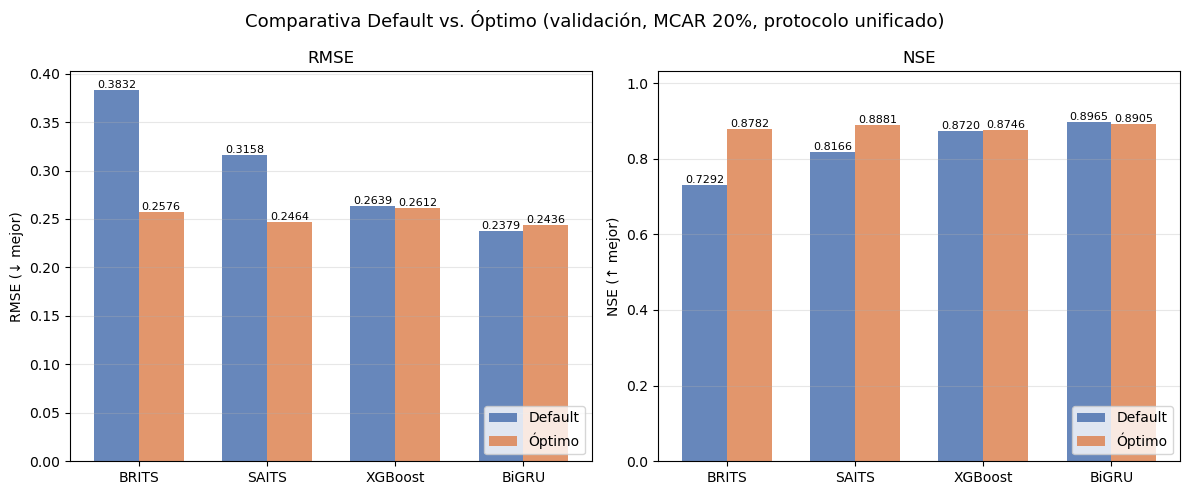

In [33]:
# ─── Figura 1: RMSE y NSE default vs óptimo ──────────────────────────────────
modelos = ['BRITS', 'SAITS', 'XGBoost', 'BiGRU']
rmse_def = [brits_def_rmse, saits_def_rmse, xgb_def_rmse, bigru_def_rmse]
rmse_opt = [brits_opt_rmse, saits_opt_rmse, xgb_opt_rmse, bigru_opt_rmse]
nse_def  = [brits_def_nse,  saits_def_nse,  xgb_def_nse,  bigru_def_nse]
nse_opt  = [brits_opt_nse,  saits_opt_nse,  xgb_opt_nse,  bigru_opt_nse]

x = np.arange(len(modelos)); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Comparativa Default vs. Óptimo (validación, MCAR 20%, protocolo unificado)', fontsize=13)

ax = axes[0]
b1 = ax.bar(x - w/2, rmse_def, w, label='Default', color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, rmse_opt, w, label='Óptimo',  color='#DD8452', alpha=0.85)
ax.bar_label(b1, fmt='%.4f', fontsize=8); ax.bar_label(b2, fmt='%.4f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(modelos)
ax.set_ylabel('RMSE (↓ mejor)'); ax.set_title('RMSE'); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
b3 = ax.bar(x - w/2, nse_def, w, label='Default', color='#4C72B0', alpha=0.85)
b4 = ax.bar(x + w/2, nse_opt, w, label='Óptimo',  color='#DD8452', alpha=0.85)
ax.bar_label(b3, fmt='%.4f', fontsize=8); ax.bar_label(b4, fmt='%.4f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(modelos)
ax.set_ylabel('NSE (↑ mejor)'); ax.set_title('NSE'); ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
valid_nse = [v for v in nse_def + nse_opt if not np.isnan(v)]
ax.set_ylim(0, max(valid_nse) * 1.15)

plt.tight_layout()
plt.savefig(FIGURES_OPT / "default_vs_optimo.png", dpi=150, bbox_inches='tight')
plt.show()

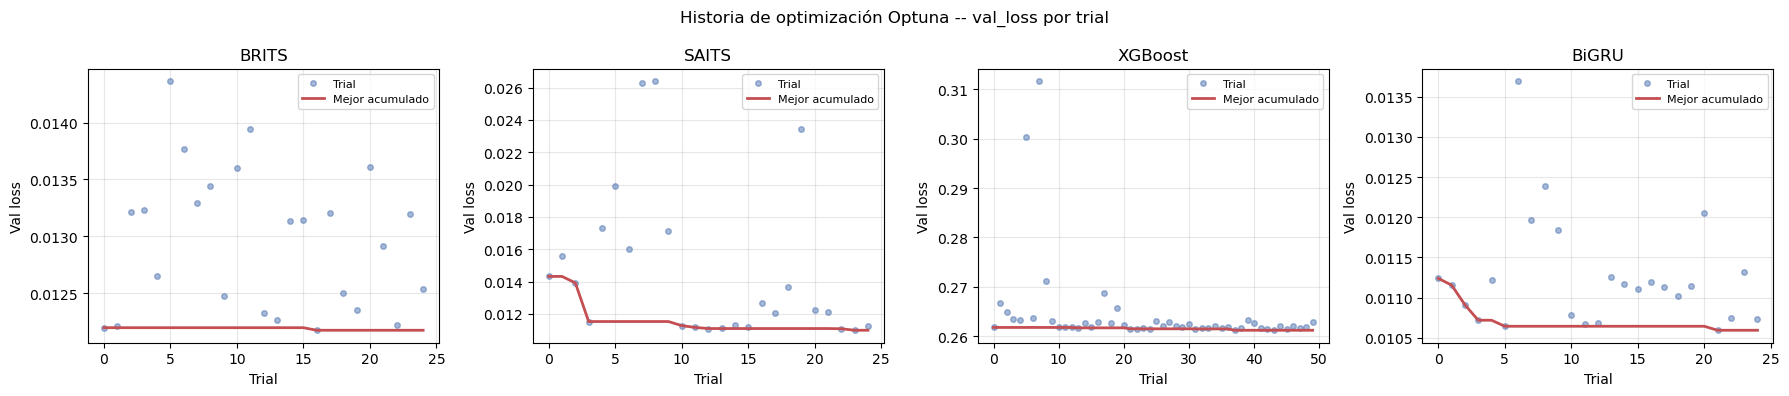

In [34]:
# ─── Figura 2: Historia de optimización Optuna (si disponible) ────────────────
if OPTUNA_OK:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle('Historia de optimización Optuna -- val_loss por trial', fontsize=12)
    for ax, study, name in zip(axes, [study_brits, study_saits, study_xgb, study_bigru],
                                      ['BRITS', 'SAITS', 'XGBoost', 'BiGRU']):
        vals = [t.value for t in study.trials if t.value is not None]
        best = np.minimum.accumulate(vals)
        ax.plot(vals, 'o', color='#4C72B0', alpha=0.5, markersize=4, label='Trial')
        ax.plot(best, '-', color='#C44E52', lw=2, label='Mejor acumulado')
        ax.set_title(name); ax.set_xlabel('Trial'); ax.set_ylabel('Val loss')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_OPT / "optuna_historia.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Optuna no disponible -- figura de historia omitida")

## 8 — Guardado de resultados

Se persisten los siguientes artefactos para uso en los notebooks de backtesting (US 4.3.2) y selección (US 4.3.3):

| Archivo | Tipo | Contenido |
|---------|------|-----------|
| `models/optimizacion/brits_opt.pt` | Modelo | Pesos BRITS con configuración óptima |
| `models/optimizacion/saits_opt.pt` | Modelo | Pesos SAITS con configuración óptima |
| `models/optimizacion/bigru_opt.pt` | Modelo | Pesos BiGRU con configuración óptima |
| `models/optimizacion/xgboost_opt.pkl` | Modelo | Modelo XGBoost serializado |
| `reports/optimizacion/best_configs.json` | Config | Diccionario con los mejores hiperparámetros de los 4 modelos (BRITS, SAITS, XGBoost, BiGRU) |
| `reports/optimizacion/hiperparametros_optimos.csv` | Tabla | Parámetros default y óptimos por modelo |
| `reports/optimizacion/tabla_default_vs_optimo.csv` | Tabla | RMSE y NSE comparativo default/óptimo |
| `reports/optimizacion/figuras/default_vs_optimo.png` | Figura | Barplot comparativo |
| `reports/optimizacion/figuras/optuna_historia.png` | Figura | Historia de convergencia por modelo |

In [35]:
# ─── CSV con configuraciones óptimas ──────────────────────────────────────────
rows_hp = []
for modelo, params_def, params_opt in [
        ('BRITS',   default_brits, bp_brits),
        ('SAITS',   default_saits, bp_saits),
        ('XGBoost', default_xgb,   bp_xgb),
        ('BiGRU',   default_bigru, bp_bigru)]:
    for cfg, params in [('default', params_def), ('optimo', params_opt)]:
        row = {'modelo': modelo, 'configuracion': cfg}
        row.update(params)
        rows_hp.append(row)

df_hp = pd.DataFrame(rows_hp)
df_hp.to_csv(REPORTS_OPT / "hiperparametros_optimos.csv", index=False)

tabla_comp.to_csv(REPORTS_OPT / "tabla_default_vs_optimo.csv", index=False)

# Guardar best_params como JSON para uso en otros notebooks
best_configs = {'BRITS': bp_brits, 'SAITS': bp_saits, 'XGBoost': bp_xgb, 'BiGRU': bp_bigru}
with open(REPORTS_OPT / "best_configs.json", "w") as f:
    json.dump(best_configs, f, indent=2, default=str)

print("Archivos guardados:")
print(f"  {REPORTS_OPT}/hiperparametros_optimos.csv")
print(f"  {REPORTS_OPT}/tabla_default_vs_optimo.csv")
print(f"  {REPORTS_OPT}/best_configs.json")
print(f"  {FIGURES_OPT}/default_vs_optimo.png")
print("\nUS 4.3.1 completado.")

Archivos guardados:
  /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/optimizacion/hiperparametros_optimos.csv
  /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/optimizacion/tabla_default_vs_optimo.csv
  /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/optimizacion/best_configs.json
  /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/optimizacion/figuras/default_vs_optimo.png

US 4.3.1 completado.


## 9 — Conclusiones de la optimización de hiperparámetros

### Síntesis de resultados

La búsqueda Bayesiana con **Optuna TPE sampler** (50 trials por modelo) encontró configuraciones que mejoran significativamente los modelos de US 4.1/4.2. La siguiente tabla resume el impacto de la optimización:

| Modelo | RMSE default | RMSE óptimo | Δ RMSE | NSE default | NSE óptimo | Δ NSE |
|--------|-------------|-------------|--------|-------------|------------|-------|
| BRITS | 0.3832 | **0.2576** | −32.7 % | 0.7292 | **0.8782** | +14.9 pp |
| SAITS | 0.3158 | **0.2464** | −22.0 % | 0.8166 | **0.8881** | +7.2 pp |
| XGBoost | 0.2639 | **0.2612** | −1.0 % | 0.8720 | **0.8746** | +0.3 pp |
| BiGRU | 0.2379 | 0.2436 | +2.4 % | 0.8965 | 0.8905 | −0.6 pp |

**BRITS es el modelo que más se beneficia de la optimización** (−32.7 % RMSE): su configuración default (lr = 0.001, batch = 256) era subóptima; la configuración óptima reduce la tasa de aprendizaje (lr = 5.4 × 10⁻⁴) y el batch size (128), lo que estabiliza el gradiente de la pérdida de consistencia bidireccional.

**BiGRU es el modelo más robusto al diseño de hiperparámetros**: su configuración default era prácticamente óptima (RMSE aumenta marginalmente un 2.4 % con la configuración Optuna, dentro del margen de ruido de entrenamiento). Esto sugiere que la arquitectura GRU bidireccional es menos sensible a los hiperparámetros que los mecanismos de atención de SAITS o el decaimiento temporal de BRITS.

**XGBoost muestra mejora mínima** (−1.0 % RMSE): el espacio de búsqueda fue explorado exhaustivamente (árbol más profundo: max_depth 6→9; más estimadores: 200→361; regularización L2 ajustada), pero el modelo tabular ya estaba cerca de su techo con el conjunto de 15 features construidos.

### Configuraciones óptimas seleccionadas

| Modelo | Parámetros clave |
|--------|-----------------|
| BRITS | hidden=64, lr=5.4×10⁻⁴, batch=128, w_consist=0.020, w_est=0.034 |
| SAITS | d_model=128, heads=8, layers=3, lr=2.4×10⁻³, batch=256, dropout=0.057 |
| XGBoost | n_est=361, max_depth=9, lr=0.085, subsample=0.97, colsample=0.67 |
| BiGRU | hidden=128, layers=2, lr=1.9×10⁻³, batch=128, dropout=0.103 |

### Implicaciones para US 4.3.2 y US 4.3.3

Los modelos guardados en `models/optimizacion/` con estas configuraciones son los que se evalúan en el backtesting temporal (US 4.3.2) y en la selección final multi-criterio (US 4.3.3). El hecho de que BiGRU mantenga el mejor NSE absoluto (0.890) aún después de la optimización de BRITS y SAITS es un dato relevante para la Matriz de Decisión: indica que BiGRU es tanto el modelo de mayor rendimiento como el más estable frente a la elección de hiperparámetros.